In [1]:
def predict_weather(input_data):
    # Convert input to DataFrame with correct feature names
    input_df = pd.DataFrame(
        input_data,
        columns=features
    )

    # Rainfall prediction
    rainfall = rainfall_model.predict(input_df)[0]

    # Rain probability
    rain_probability = rain_classifier.predict_proba(input_df)[0][1]

    # Weather condition
    if rain_probability >= 0.5:
        condition = "Rain"
    else:
        condition = "No Rain"

    return {
        "predicted_rainfall": rainfall,
        "rain_probability": rain_probability * 100,
        "weather_condition": condition
    }


# Test the function
result = predict_weather([[
    28.0,
    24.0,
    32.0,
    10.0,
    1008.0,
    50.0,
    16.98,
    82.24,
    9,
    2,
    8.0
]])

print(result)

NameError: name 'pd' is not defined

In [108]:
if rain_probability >= 0.5:
    weather_condition = "Rain"
else:
    weather_condition = "No Rain"

print("Weather Condition:", weather_condition)

Weather Condition: Rain


In [107]:
rain_probability = rain_classifier.predict_proba(sample_input)[0][1]

print("Rain Probability:", rain_probability * 100, "%")

Rain Probability: 88.0 %


In [106]:
rainfall_prediction = rainfall_model.predict(sample_input)

print("Predicted Rainfall:", rainfall_prediction[0], "mm")

Predicted Rainfall: 13.582999999999995 mm


In [105]:
import pandas as pd

sample_input = pd.DataFrame([[
    28.0,    # avg_temp
    24.0,    # min_temp
    32.0,    # max_temp
    10.0,    # wind_speed
    1008.0,  # air_pressure
    50.0,    # elevation
    16.98,   # latitude
    82.24,   # longitude
    9,       # month
    2,       # season_code
    8.0      # temp_range
]], columns=features)

print(sample_input)

   avg_temp  min_temp  max_temp  wind_speed  air_pressure  elevation  \
0      28.0      24.0      32.0        10.0        1008.0       50.0   

   latitude  longitude  month  season_code  temp_range  
0     16.98      82.24      9            2         8.0  


In [104]:
rainfall_prediction = rainfall_model.predict(sample_input)

print("Predicted Rainfall:", rainfall_prediction[0], "mm")

C:\Users\Sudheer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Predicted Rainfall: 13.582999999999995 mm


In [103]:
sample_input = [[
    28.0,   # avg_temp
    24.0,   # min_temp
    32.0,   # max_temp
    10.0,   # wind_speed
    1008.0, # air_pressure
    50.0,   # elevation
    16.98,  # latitude
    82.24,  # longitude
    9,      # month
    2,      # season_code
    8.0     # temp_range
]]

print("Sample weather input created!")
print("Number of features:", len(sample_input[0]))

Sample weather input created!
Number of features: 11


In [102]:
import joblib

# Load saved models
rainfall_model = joblib.load("../models/random_forest_model.pkl")
rain_classifier = joblib.load("../models/rain_classifier.pkl")

print("Rainfall model loaded successfully!")
print("Rain/No-Rain classifier loaded successfully!")

Rainfall model loaded successfully!
Rain/No-Rain classifier loaded successfully!


In [101]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    rf_classifier,
    "../models/rain_classifier.pkl"
)

print("Rain/No-Rain classifier saved successfully!")

Rain/No-Rain classifier saved successfully!


In [100]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(yc_test, yc_pred)
precision = precision_score(yc_test, yc_pred)
recall = recall_score(yc_test, yc_pred)
f1 = f1_score(yc_test, yc_pred)

print("Rain/No-Rain Classification Results")
print("------------------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Rain/No-Rain Classification Results
------------------------------------
Accuracy : 0.8524812189186329
Precision: 0.8423749375579819
Recall   : 0.8567426331833358
F1-Score : 0.8494980389334676


In [99]:
yc_pred = rf_classifier.predict(Xc_test)

print("Predictions generated successfully!")
print("First 20 predictions:")
print(yc_pred[:20])

Predictions generated successfully!
First 20 predictions:
[1 0 1 1 0 0 0 0 0 1 0 1 1 1 0 0 0 0 1 0]


In [98]:
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_classifier.fit(Xc_train, yc_train)

print("Rain/No-Rain classifier trained successfully!")

Rain/No-Rain classifier trained successfully!


In [97]:
from sklearn.model_selection import train_test_split

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_class,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

print("Xc_train shape:", Xc_train.shape)
print("Xc_test shape:", Xc_test.shape)
print("yc_train shape:", yc_train.shape)
print("yc_test shape:", yc_test.shape)

Xc_train shape: (567057, 11)
Xc_test shape: (141765, 11)
yc_train shape: (567057,)
yc_test shape: (141765,)


In [96]:
classification_target = "rain_flag"

X_class = df[features]
y_class = df[classification_target]

print("Classification target:", classification_target)
print("X_class shape:", X_class.shape)
print("y_class shape:", y_class.shape)

Classification target: rain_flag
X_class shape: (708822, 11)
y_class shape: (708822,)


In [95]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(rf_model, "../models/random_forest_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

print("Random Forest model saved successfully!")
print("Scaler saved successfully!")

Random Forest model saved successfully!
Scaler saved successfully!


In [94]:
results = {
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        mae,
        rf_mae,
        gb_mae
    ],
    "MSE": [
        mse,
        rf_mse,
        gb_mse
    ],
    "RMSE": [
        rmse,
        rf_rmse,
        gb_rmse
    ],
    "R2": [
        r2,
        rf_r2,
        gb_r2
    ]
}

results_df = pd.DataFrame(results)

print(results_df.round(4))

               Model     MAE       MSE     RMSE      R2
0  Linear Regression  6.6071  180.7460  13.4442  0.1270
1      Random Forest  4.3383  113.5994  10.6583  0.4513
2  Gradient Boosting  5.1538  143.7143  11.9881  0.3058


In [93]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

gb_mae = mean_absolute_error(y_test, gb_pred)
gb_mse = mean_squared_error(y_test, gb_pred)
gb_rmse = np.sqrt(gb_mse)
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting Results")
print("-------------------------")
print("MAE :", gb_mae)
print("MSE :", gb_mse)
print("RMSE:", gb_rmse)
print("R²  :", gb_r2)

Gradient Boosting Results
-------------------------
MAE : 5.1537844225634
MSE : 143.7143094658221
RMSE: 11.988090317720422
R²  : 0.3058260057768094


In [99]:
gb_pred = gb_model.predict(X_test)

print("Gradient Boosting predictions generated successfully!")
print("First 10 predictions:")
print(gb_pred[:10])

Gradient Boosting predictions generated successfully!
First 10 predictions:
[8.52211859 3.33681203 2.91189514 6.88348275 4.27832841 0.150647
 8.97921777 0.3272275  0.0196367  1.20447701]


In [98]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully!")

Gradient Boosting model trained successfully!


In [97]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("---------------------")
print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest Results
---------------------
MAE : 4.338280543319627
MSE : 113.59937872997459
RMSE: 10.658300930728808
R²  : 0.45128822058590334


In [96]:
rf_pred = rf_model.predict(X_test)

print("Random Forest predictions generated successfully!")
print("First 10 predictions:")
print(rf_pred[:10])

Random Forest predictions generated successfully!
First 10 predictions:
[5.4830e+00 2.0000e-01 3.2500e-01 3.4710e+00 3.1180e+00 1.3400e-01
 1.1894e+01 3.3000e-02 1.0000e-03 0.0000e+00]


In [95]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [93]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Linear Regression Results
-------------------------
MAE : 6.60709142762839
MSE : 180.74595762011725
RMSE: 13.444179321182727
R²  : 0.12695441527559814


In [90]:
y_pred = model.predict(X_test_scaled)

print("Predictions generated successfully!")
print("First 10 predictions:")
print(y_pred[:10])

Predictions generated successfully!
First 10 predictions:
[13.83921738  3.75791408 -0.3723657  -0.30595738  6.05701658 -1.07464513
 11.22330525  0.38309514  2.38602873  3.50804441]


In [89]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [88]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (567057, 11)
X_test_scaled shape: (141765, 11)


In [87]:
from sklearn.preprocessing import StandardScaler

In [85]:
print("Number of features:", len(features))
print("Features:", features)
print("X columns:", X.columns.tolist())

Number of features: 11
Features: ['avg_temp', 'min_temp', 'max_temp', 'wind_speed', 'air_pressure', 'elevation', 'latitude', 'longitude', 'month', 'season_code', 'temp_range']
X columns: ['avg_temp', 'min_temp', 'max_temp', 'wind_speed', 'air_pressure', 'elevation', 'latitude', 'longitude', 'month', 'season_code', 'temp_range']


In [84]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (567057, 11)
X_test: (141765, 11)
y_train: (567057,)
y_test: (141765,)


In [83]:
from sklearn.model_selection import train_test_split

In [81]:
X = df[features]
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (708822, 11)
y shape: (708822,)


,avg_temp,min_temp,max_temp,wind_speed,air_pressure,elevation,latitude,longitude,month,season_code,temp_range
0,-2.2,-6.6,-0.8,2.2,1020.0,2652,34.05,74.4,1,0,5.8
1,-3.6,-4.6,-1.8,3.7,1019.5,2652,34.05,74.4,1,0,2.8
2,-3.0,-4.5,-1.1,2.1,1022.0,2652,34.05,74.4,1,0,3.4
3,-3.3,-5.1,-1.2,2.8,1015.6,2652,34.05,74.4,1,0,3.9
4,-3.9,-8.3,-1.0,3.4,1015.3,2652,34.05,74.4,1,0,7.3


In [80]:
features = [
    "avg_temp",
    "min_temp",
    "max_temp",
    "wind_speed",
    "air_pressure",
    "elevation",
    "latitude",
    "longitude",
    "month",
    "season_code",
    "temp_range"
]

print("Number of features:", len(features))
print("Features:", features)

Number of features: 11
Features: ['avg_temp', 'min_temp', 'max_temp', 'wind_speed', 'air_pressure', 'elevation', 'latitude', 'longitude', 'month', 'season_code', 'temp_range']


In [79]:
target = "rainfall"

print("Target column:", target)
print("Target data type:", df[target].dtype)

Target column: rainfall
Target data type: float64


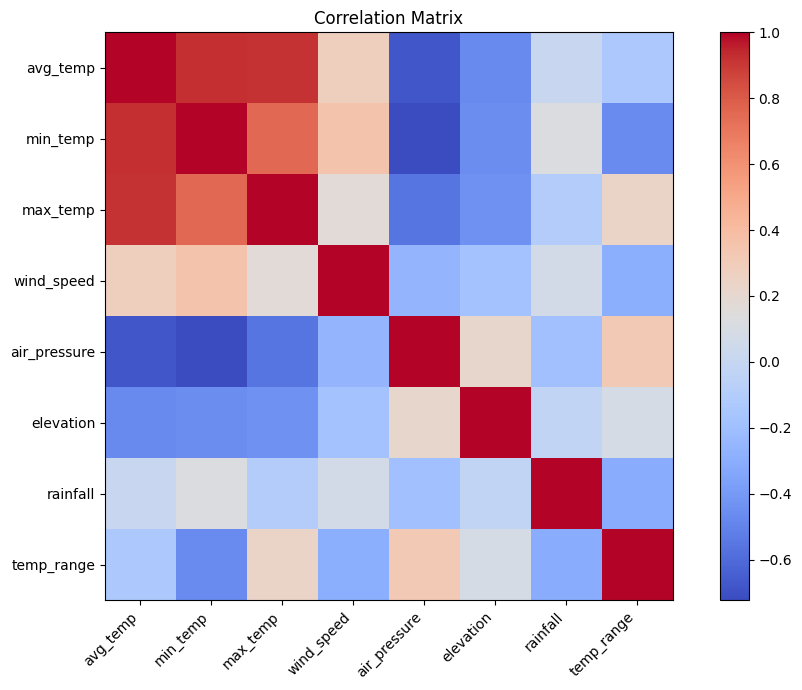

In [78]:
plt.figure(figsize=(10, 7))

plt.imshow(correlation, cmap="coolwarm", interpolation="nearest")

plt.colorbar()

plt.xticks(
    range(len(numeric_cols)),
    numeric_cols,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(numeric_cols)),
    numeric_cols
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

In [77]:
numeric_cols = [
    "avg_temp",
    "min_temp",
    "max_temp",
    "wind_speed",
    "air_pressure",
    "elevation",
    "rainfall",
    "temp_range"
]

correlation = df[numeric_cols].corr()

print(correlation.round(2))

              avg_temp  min_temp  max_temp  wind_speed  air_pressure  \
avg_temp          1.00      0.93      0.91        0.28         -0.68   
min_temp          0.93      1.00      0.75        0.36         -0.72   
max_temp          0.91      0.75      1.00        0.17         -0.56   
wind_speed        0.28      0.36      0.17        1.00         -0.26   
air_pressure     -0.68     -0.72     -0.56       -0.26          1.00   
elevation        -0.47     -0.46     -0.44       -0.18          0.22   
rainfall          0.01      0.12     -0.10        0.07         -0.19   
temp_range       -0.14     -0.46      0.24       -0.30          0.32   

              elevation  rainfall  temp_range  
avg_temp          -0.47      0.01       -0.14  
min_temp          -0.46      0.12       -0.46  
max_temp          -0.44     -0.10        0.24  
wind_speed        -0.18      0.07       -0.30  
air_pressure       0.22     -0.19        0.32  
elevation          1.00     -0.02        0.09  
rainfall       

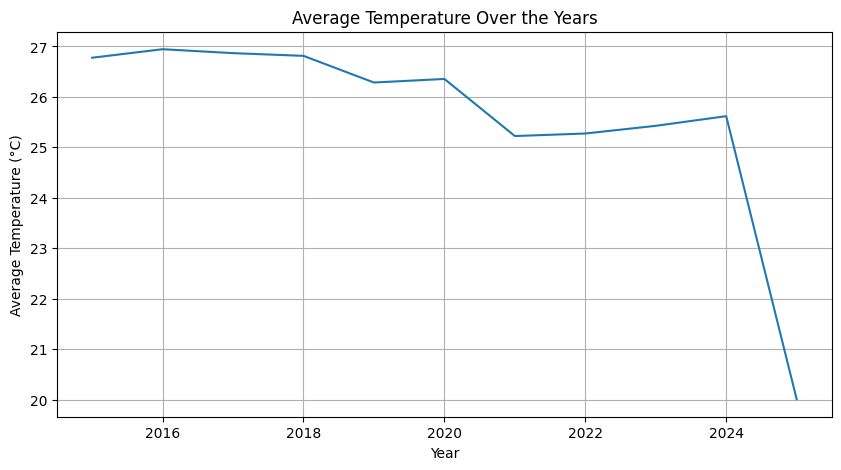

In [75]:
plt.figure(figsize=(10, 5))

plt.plot(yearly_temp.index, yearly_temp.values)

plt.xlabel("Year")
plt.ylabel("Average Temperature (°C)")
plt.title("Average Temperature Over the Years")

plt.grid(True)

plt.show()

In [74]:
yearly_temp = df.groupby("year")["avg_temp"].mean()

print(yearly_temp)

year
2015    26.776208
2016    26.944872
2017    26.867159
2018    26.813349
2019    26.284904
2020    26.355753
2021    25.224342
2022    25.274592
2023    25.426988
2024    25.618467
2025    20.008771
Name: avg_temp, dtype: float64


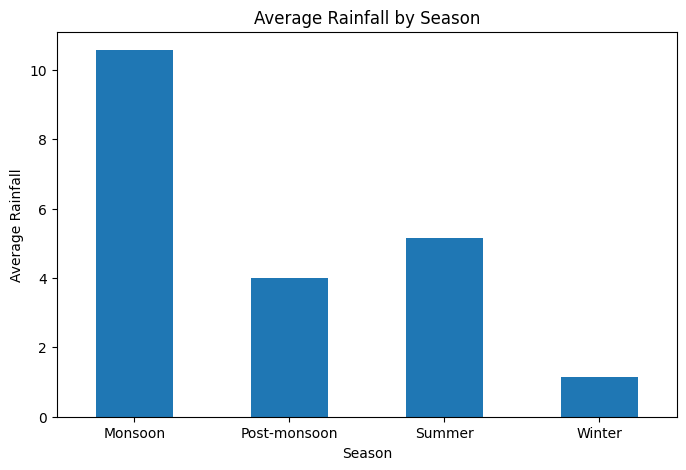

In [73]:
season_rainfall.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Season")
plt.ylabel("Average Rainfall")
plt.title("Average Rainfall by Season")

plt.xticks(rotation=0)

plt.show()

In [72]:
season_rainfall = df.groupby("season")["rainfall"].mean()

print(season_rainfall)

season
Monsoon         10.573993
Post-monsoon     4.010629
Summer           5.150433
Winter           1.139099
Name: rainfall, dtype: float64


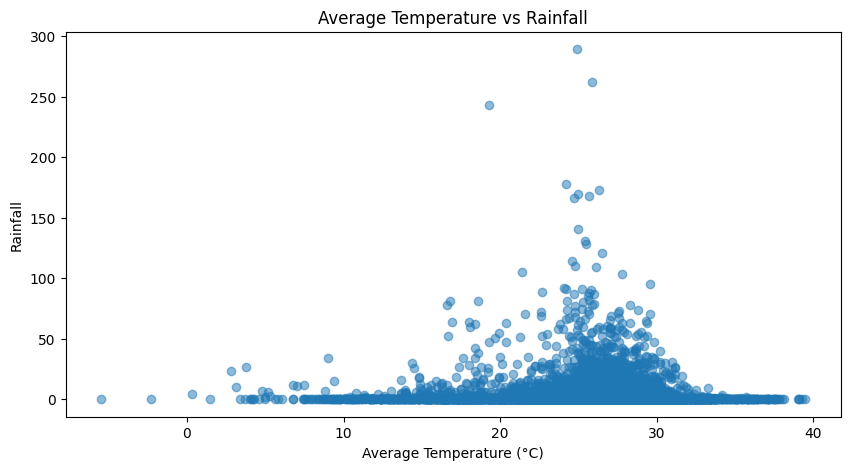

In [70]:
sample_df = df.sample(5000, random_state=42)

plt.figure(figsize=(10, 5))

plt.scatter(
    sample_df["avg_temp"],
    sample_df["rainfall"],
    alpha=0.5
)

plt.xlabel("Average Temperature (°C)")
plt.ylabel("Rainfall")
plt.title("Average Temperature vs Rainfall")

plt.show()

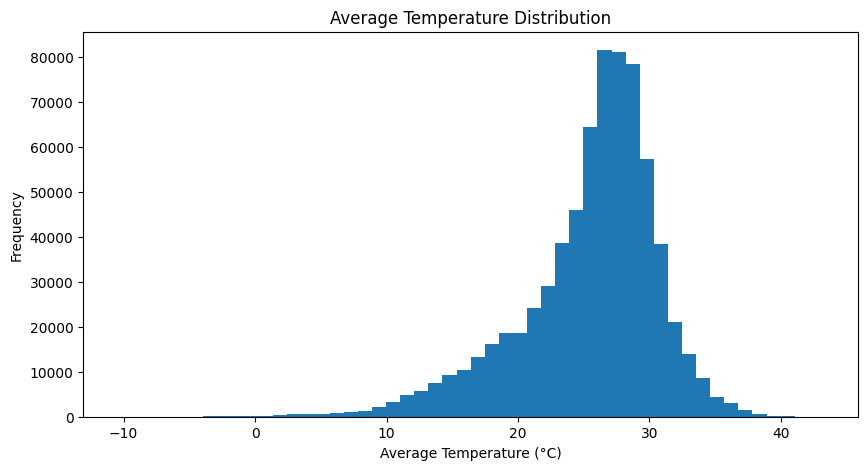

In [69]:
plt.figure(figsize=(10, 5))

plt.hist(df["avg_temp"], bins=50)

plt.xlabel("Average Temperature (°C)")
plt.ylabel("Frequency")
plt.title("Average Temperature Distribution")

plt.show()

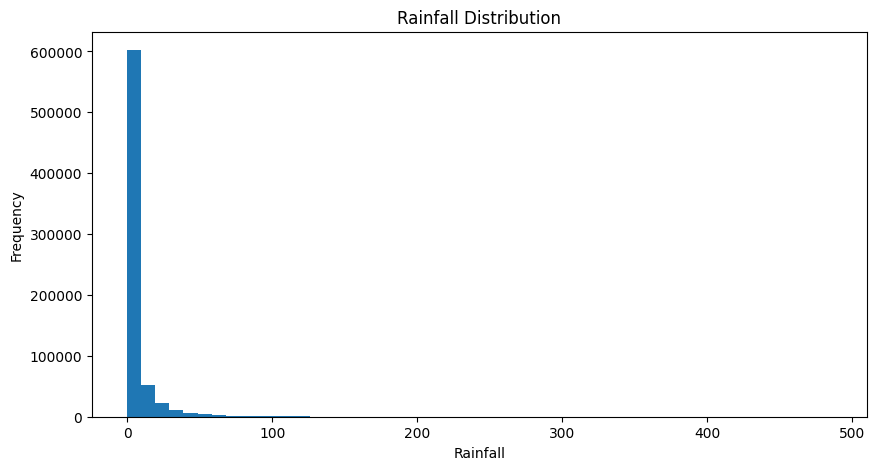

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(df["rainfall"], bins=50)

plt.xlabel("Rainfall")
plt.ylabel("Frequency")
plt.title("Rainfall Distribution")

plt.show()

In [67]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum().sum())

Shape: (708822, 21)

Columns:
['date_of_record', 'month', 'season', 'station_name', 'state', 'district', 'avg_temp', 'min_temp', 'max_temp', 'wind_speed', 'air_pressure', 'elevation', 'latitude', 'longitude', 'rainfall', 'year', 'day', 'day_of_week', 'temp_range', 'rain_flag', 'season_code']

Missing values:
0


In [66]:
print(df[["latitude", "longitude", "elevation"]].isnull().sum())

latitude     0
longitude    0
elevation    0
dtype: int64


In [65]:
print("States:", df["state"].nunique())
print("Districts:", df["district"].nunique())
print("Stations:", df["station_name"].nunique())

States: 32
Districts: 314
Stations: 406


In [64]:
season_mapping = {
    "Winter": 0,
    "Summer": 1,
    "Monsoon": 2,
    "Post-monsoon": 3
}

df["season_code"] = df["season"].map(season_mapping)

print(df[["season", "season_code"]].drop_duplicates().sort_values("season_code"))

           season  season_code
0          Winter            0
89         Summer            1
180       Monsoon            2
272  Post-monsoon            3


In [63]:
print(df["season"].value_counts())

season
Winter          220840
Monsoon         202599
Summer          172176
Post-monsoon    113207
Name: count, dtype: int64


In [62]:
print("Month mismatches:",
      (df["month"] != df["date_of_record"].dt.month).sum())

Month mismatches: 0


In [61]:
print(df.columns.tolist())

['date_of_record', 'month', 'season', 'station_name', 'state', 'district', 'avg_temp', 'min_temp', 'max_temp', 'wind_speed', 'air_pressure', 'elevation', 'latitude', 'longitude', 'rainfall', 'year', 'day', 'day_of_week', 'temp_range', 'rain_flag']


In [60]:
print(df["rain_flag"].value_counts())

rain_flag
0    364372
1    344450
Name: count, dtype: int64


In [59]:
df["rain_flag"] = (df["rainfall"] > 0).astype(int)

print(df[["rainfall", "rain_flag"]].head(10))

   rainfall  rain_flag
0       0.1          1
1       4.4          1
2       2.3          1
3      35.0          1
4      25.5          1
5       0.0          0
6       0.0          0
7       0.0          0
8       0.0          0
9       0.0          0


In [58]:
df = df[df["temp_range"] >= 0].copy()

print(df.shape)
print("Negative temp_range:", (df["temp_range"] < 0).sum())

(708822, 19)
Negative temp_range: 0


In [57]:
print("Missing:", df["temp_range"].isnull().sum())
print("Negative:", (df["temp_range"] < 0).sum())
print(df["temp_range"].describe())

Missing: 0
Negative: 0
count    708822.000000
mean         10.051510
std           3.942676
min           0.300000
25%           7.100000
50%           9.700000
75%          12.900000
max          37.000000
Name: temp_range, dtype: float64


In [56]:
df["temp_range"] = df["max_temp"] - df["min_temp"]

print(df[["min_temp", "max_temp", "temp_range"]].head())

   min_temp  max_temp  temp_range
0      -6.6      -0.8         5.8
1      -4.6      -1.8         2.8
2      -4.5      -1.1         3.4
3      -5.1      -1.2         3.9
4      -8.3      -1.0         7.3


In [55]:
df["year"] = df["date_of_record"].dt.year
df["month"] = df["date_of_record"].dt.month
df["day"] = df["date_of_record"].dt.day
df["day_of_week"] = df["date_of_record"].dt.dayofweek

print(df[["date_of_record", "year", "month", "day", "day_of_week"]].head())

  date_of_record  year  month  day  day_of_week
0     2021-01-02  2021      1    2            5
1     2021-01-03  2021      1    3            6
2     2021-01-04  2021      1    4            0
3     2021-01-05  2021      1    5            1
4     2021-01-06  2021      1    6            2


In [54]:
df["date_of_record"] = pd.to_datetime(df["date_of_record"])

print(df["date_of_record"].dtype)

datetime64[ns]


In [53]:
df[["avg_temp", "min_temp", "max_temp", "wind_speed",
    "air_pressure", "elevation", "rainfall"]].describe()

,avg_temp,min_temp,max_temp,wind_speed,air_pressure,elevation,rainfall
count,708822.000000,708822.000000,708822.000000,708822.000000,708822.000000,708822.000000,708822.000000
mean,25.457698,20.840375,30.891885,9.487293,1009.396953,309.868637,5.268814
std,5.294678,5.807636,5.294043,4.871126,4.959892,430.576780,14.447665
min,-10.400000,-18.500000,-5.600000,0.000000,960.800000,0.000000,0.000000
25%,23.100000,17.700000,28.400000,6.200000,1006.400000,15.000000,0.000000
50%,26.600000,22.600000,31.200000,8.400000,1009.500000,140.000000,0.000000
75%,28.800000,25.000000,34.000000,11.500000,1012.800000,458.000000,4.000000
max,43.200000,36.600000,52.400000,66.600000,1036.500000,2652.000000,485.900000


In [52]:
print(df.isnull().sum())

date_of_record    0
month             0
season            0
station_name      0
state             0
district          0
avg_temp          0
min_temp          0
max_temp          0
wind_speed        0
air_pressure      0
elevation         0
latitude          0
longitude         0
rainfall          0
dtype: int64


In [51]:
df = df.dropna(subset=["rainfall"])

print(df.shape)

(708822, 15)


In [50]:

df["wind_speed"] = df["wind_speed"].fillna(
    df.groupby("station_name")["wind_speed"].transform("median")
)

df["air_pressure"] = df["air_pressure"].fillna(
    df.groupby("station_name")["air_pressure"].transform("median")
)

print(df[["wind_speed", "air_pressure"]].isnull().sum())


wind_speed      0
air_pressure    0
dtype: int64


In [49]:
df["min_temp"] = df["min_temp"].fillna(
    df.groupby("station_name")["min_temp"].transform("median")
)

df["max_temp"] = df["max_temp"].fillna(
    df.groupby("station_name")["max_temp"].transform("median")
)

print(df[["min_temp", "max_temp"]].isnull().sum())

min_temp    0
max_temp    0
dtype: int64


In [48]:
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

In [47]:
print(df.isnull().sum())

date_of_record    0
month             0
season            0
station_name      0
state             0
district          0
avg_temp          0
min_temp          0
max_temp          0
wind_speed        0
air_pressure      0
elevation         0
latitude          0
longitude         0
rainfall          0
dtype: int64


In [46]:
print("min_temp > avg_temp:",
      (df["min_temp"] > df["avg_temp"]).sum())

print("avg_temp > max_temp:",
      (df["avg_temp"] > df["max_temp"]).sum())

print("min_temp > max_temp:",
      (df["min_temp"] > df["max_temp"]).sum())

min_temp > avg_temp: 0
avg_temp > max_temp: 0
min_temp > max_temp: 0


In [45]:
print("min > avg:", (df["min_temp"] > df["avg_temp"]).sum())
print("avg > max:", (df["avg_temp"] > df["max_temp"]).sum())
print("min > max:", (df["min_temp"] > df["max_temp"]).sum())

min > avg: 0
avg > max: 0
min > max: 0


In [44]:
df = df[
    (df["min_temp"] <= df["avg_temp"]) &
    (df["avg_temp"] <= df["max_temp"])
].copy()

print(df.shape)

(708822, 15)


In [43]:
print("min_temp > avg_temp:",
      (df["min_temp"] > df["avg_temp"]).sum())

print("avg_temp > max_temp:",
      (df["avg_temp"] > df["max_temp"]).sum())

print("min_temp > max_temp:",
      (df["min_temp"] > df["max_temp"]).sum())

min_temp > avg_temp: 1509
avg_temp > max_temp: 2454
min_temp > max_temp: 196


In [42]:
df.isnull().sum().sum()

np.int64(0)

In [41]:
df.isnull().sum()

date_of_record    0
month             0
season            0
station_name      0
state             0
district          0
avg_temp          0
min_temp          0
max_temp          0
wind_speed        0
air_pressure      0
elevation         0
latitude          0
longitude         0
rainfall          0
dtype: int64

In [40]:
df = df.dropna(subset=["rainfall"])

print(df.shape)

(712785, 15)


In [39]:
df["rainfall"].isnull().sum()

np.int64(257554)

In [38]:
df[["wind_speed", "air_pressure"]].isnull().sum()

wind_speed      0
air_pressure    0
dtype: int64

In [37]:
df["wind_speed"] = df["wind_speed"].fillna(
    df.groupby("station_name")["wind_speed"].transform("median")
)

df["air_pressure"] = df["air_pressure"].fillna(
    df.groupby("station_name")["air_pressure"].transform("median")
)

In [36]:
df[["min_temp", "max_temp"]].isnull().sum()

min_temp    0
max_temp    0
dtype: int64

In [35]:
# Fill missing temperature values using station-wise median

df["min_temp"] = df["min_temp"].fillna(
    df.groupby("station_name")["min_temp"].transform("median")
)

df["max_temp"] = df["max_temp"].fillna(
    df.groupby("station_name")["max_temp"].transform("median")
)

In [34]:
df.isnull().sum()

date_of_record         0
month                  0
season                 0
station_name           0
state                  0
district               0
avg_temp               0
min_temp           43898
max_temp          110598
wind_speed        274444
air_pressure      304664
elevation              0
latitude               0
longitude              0
rainfall          257554
dtype: int64

In [33]:


df = df.drop(columns=["Unnamed: 0"])

print(df.shape)

(970339, 15)


In [32]:
import pandas as pd

df = pd.read_csv("../data/weather_data.csv")

print(df.shape)

(970339, 16)


In [31]:
df[
    (df["max_temp"] < df["avg_temp"]) |
    (df["avg_temp"] < df["min_temp"]) |
    (df["max_temp"] < df["min_temp"])
][
    ["date_of_record", "station_name", "state",
     "avg_temp", "min_temp", "max_temp"]
].head(20)

,date_of_record,station_name,state,avg_temp,min_temp,max_temp
1516,2015-01-29,Srinagar,JK,2.6,22.4,9.3
1523,2015-02-05,Srinagar,JK,3.1,22.4,8.7
1527,2015-02-09,Srinagar,JK,5.6,22.4,13.2
1536,2015-02-18,Srinagar,JK,5.8,22.4,8.9
1537,2015-02-19,Srinagar,JK,2.2,22.4,31.6
1542,2015-02-24,Srinagar,JK,6.6,22.4,8.7
1547,2015-03-01,Srinagar,JK,3.0,22.4,31.6
1551,2015-03-05,Srinagar,JK,2.8,22.4,5.3
1554,2015-03-08,Srinagar,JK,1.5,22.4,3.4
1555,2015-03-09,Srinagar,JK,3.2,22.4,9.1


In [30]:
df[
    (df["max_temp"] < df["avg_temp"]) |
    (df["avg_temp"] < df["min_temp"]) |
    (df["max_temp"] < df["min_temp"])
].shape

(3981, 15)

In [29]:
df[df["max_temp"] > 50][
    ["date_of_record", "station_name", "state",
     "avg_temp", "min_temp", "max_temp"]
]

,date_of_record,station_name,state,avg_temp,min_temp,max_temp
78950,2019-06-04,Churu,RJ,39.2,30.3,50.3
658763,2021-11-03,Sangli,MH,25.7,20.8,52.4
831296,2021-11-28,Thanjavur,TN,25.3,22.8,50.2


In [28]:
(df["max_temp"] > 50).sum()

np.int64(3)

In [27]:
df[df["max_temp"] > 45]["max_temp"].value_counts().sort_index()

max_temp
45.1    62
45.2    95
45.3    50
45.4    92
45.5    27
45.6    65
45.7    35
45.8    59
45.9    28
46.0    76
46.1    27
46.2    25
46.3    11
46.4    31
46.5     9
46.6    26
46.7     6
46.8    15
46.9     8
47.0    30
47.1     6
47.2    12
47.3     3
47.4     9
47.5     5
47.6     9
47.7     2
47.8     2
47.9     1
48.0     8
48.1     4
48.2     3
48.4     2
48.5     1
48.6     3
50.0     1
50.2     1
50.3     1
52.4     1
Name: count, dtype: int64

In [26]:
df[df["max_temp"] > 50][
    ["date_of_record", "station_name", "state", "district",
     "avg_temp", "min_temp", "max_temp"]
]

,date_of_record,station_name,state,district,avg_temp,min_temp,max_temp
78950,2019-06-04,Churu,RJ,Churu,39.2,30.3,50.3
658763,2021-11-03,Sangli,MH,Sangli,25.7,20.8,52.4
831296,2021-11-28,Thanjavur,TN,Thanjavur,25.3,22.8,50.2


In [25]:
df[df["max_temp"] > 50][
    ["date_of_record", "station_name", "state", "district",
     "avg_temp", "min_temp", "max_temp"]
]

,date_of_record,station_name,state,district,avg_temp,min_temp,max_temp
78950,2019-06-04,Churu,RJ,Churu,39.2,30.3,50.3
658763,2021-11-03,Sangli,MH,Sangli,25.7,20.8,52.4
831296,2021-11-28,Thanjavur,TN,Thanjavur,25.3,22.8,50.2


In [24]:
df[["avg_temp", "min_temp", "max_temp"]].describe()

,avg_temp,min_temp,max_temp
count,712785.000000,712785.000000,712785.000000
mean,25.457442,20.865281,30.908281
std,5.315846,5.788775,5.265071
min,-10.400000,-18.500000,-5.600000
25%,23.100000,17.800000,28.400000
50%,26.600000,22.500000,31.400000
75%,28.800000,25.000000,34.000000
max,43.200000,36.600000,52.400000


In [23]:
df.isnull().sum().sum()

np.int64(0)

In [22]:
df.shape

(712785, 15)

In [21]:
df = df.dropna(subset=["rainfall"])

In [20]:
df.isnull().sum()

date_of_record         0
month                  0
season                 0
station_name           0
state                  0
district               0
avg_temp               0
min_temp               0
max_temp               0
wind_speed             0
air_pressure           0
elevation              0
latitude               0
longitude              0
rainfall          257554
dtype: int64

In [19]:
columns_to_fill = [
    "min_temp",
    "max_temp",
    "wind_speed",
    "air_pressure"
]

for col in columns_to_fill:
    df[col] = df[col].fillna(df[col].median())

In [18]:
df.columns

Index(['date_of_record', 'month', 'season', 'station_name', 'state',
       'district', 'avg_temp', 'min_temp', 'max_temp', 'wind_speed',
       'air_pressure', 'elevation', 'latitude', 'longitude', 'rainfall'],
      dtype='object')

In [17]:
df = df.drop(columns=["Unnamed: 0"])

In [16]:
df.isnull().sum()

Unnamed: 0             0
date_of_record         0
month                  0
season                 0
station_name           0
state                  0
district               0
avg_temp               0
min_temp           43898
max_temp          110598
wind_speed        274444
air_pressure      304664
elevation              0
latitude               0
longitude              0
rainfall          257554
dtype: int64

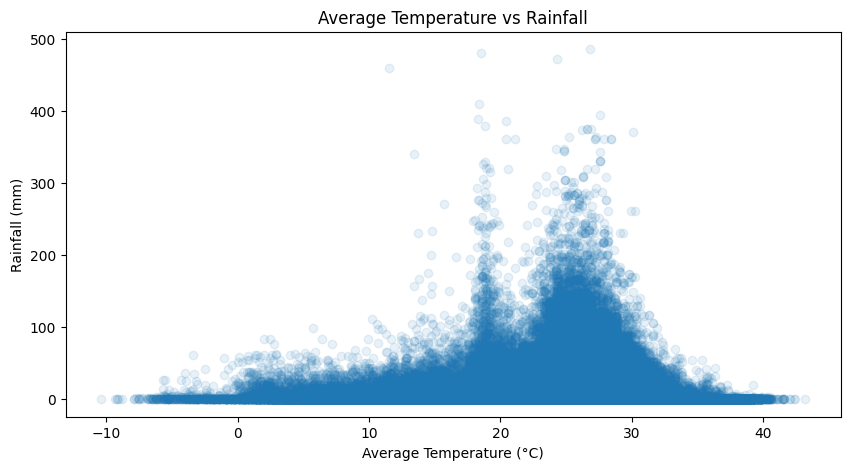

In [15]:
plt.figure(figsize=(10, 5))

plt.scatter(
    df["avg_temp"],
    df["rainfall"],
    alpha=0.1
)

plt.xlabel("Average Temperature (°C)")
plt.ylabel("Rainfall (mm)")
plt.title("Average Temperature vs Rainfall")
plt.show()

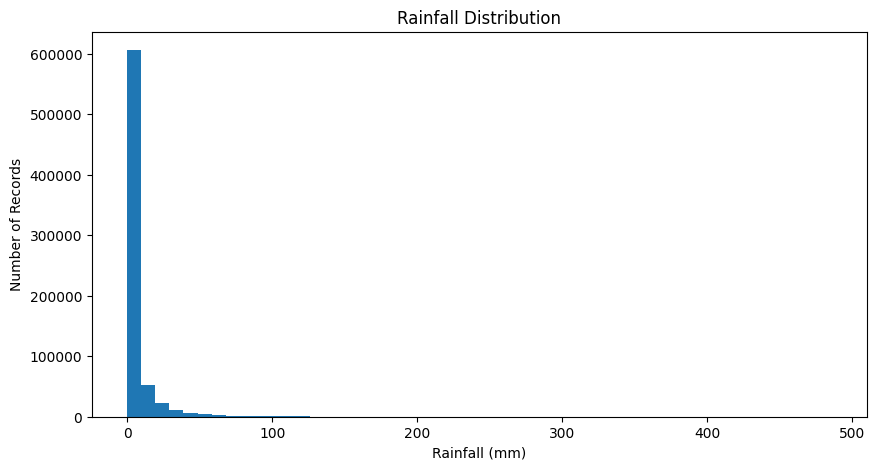

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(df["rainfall"].dropna(), bins=50)
plt.xlabel("Rainfall (mm)")
plt.ylabel("Number of Records")
plt.title("Rainfall Distribution")
plt.show()

In [13]:
df["rainfall"].value_counts().head(20)

rainfall
0.0    366240
0.3     15270
0.5     14597
1.0     12861
0.1     11770
2.0     11360
0.2     10489
3.0      8788
0.8      7953
0.4      6645
4.1      6553
5.1      6028
0.6      5233
0.7      4781
6.1      4738
7.1      4327
0.9      3987
8.9      3733
7.9      3723
1.1      3380
Name: count, dtype: int64

In [12]:
df["rainfall"].describe()

count    712785.000000
mean          5.267533
std          14.444142
min           0.000000
25%           0.000000
50%           0.000000
75%           4.000000
max         485.900000
Name: rainfall, dtype: float64

In [11]:
df.describe()

,Unnamed: 0,avg_temp,min_temp,max_temp,wind_speed,air_pressure,elevation,latitude,longitude,rainfall
count,970339.000000,970339.000000,926441.000000,859741.000000,695895.000000,665675.000000,970339.000000,970339.000000,970339.000000,712785.000000
mean,485169.000000,25.661709,20.647342,31.195383,9.432732,1009.437663,298.181018,20.793670,79.426826,5.267533
std,280112.885765,5.438133,6.008171,5.464499,4.979263,5.292871,415.266215,6.328275,5.852512,14.444142
min,0.000000,-10.400000,-18.500000,-5.600000,0.000000,922.600000,0.000000,7.983300,68.850000,0.000000
25%,242584.500000,23.100000,17.100000,28.500000,6.100000,1005.800000,16.000000,15.850000,75.400000,0.000000
50%,485169.000000,26.700000,22.400000,31.600000,8.400000,1009.800000,139.000000,21.616700,78.066700,0.000000
75%,727753.500000,29.100000,25.000000,34.400000,11.600000,1013.300000,436.000000,25.566700,82.716700,4.000000
max,970338.000000,43.400000,36.600000,87.000000,66.600000,1036.500000,2652.000000,34.083300,95.383300,485.900000


In [10]:
df.isnull().sum()

Unnamed: 0             0
date_of_record         0
month                  0
season                 0
station_name           0
state                  0
district               0
avg_temp               0
min_temp           43898
max_temp          110598
wind_speed        274444
air_pressure      304664
elevation              0
latitude               0
longitude              0
rainfall          257554
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,Unnamed: 0,avg_temp,min_temp,max_temp,wind_speed,air_pressure,elevation,latitude,longitude,rainfall
count,970339.000000,970339.000000,926441.000000,859741.000000,695895.000000,665675.000000,970339.000000,970339.000000,970339.000000,712785.000000
mean,485169.000000,25.661709,20.647342,31.195383,9.432732,1009.437663,298.181018,20.793670,79.426826,5.267533
std,280112.885765,5.438133,6.008171,5.464499,4.979263,5.292871,415.266215,6.328275,5.852512,14.444142
min,0.000000,-10.400000,-18.500000,-5.600000,0.000000,922.600000,0.000000,7.983300,68.850000,0.000000
25%,242584.500000,23.100000,17.100000,28.500000,6.100000,1005.800000,16.000000,15.850000,75.400000,0.000000
50%,485169.000000,26.700000,22.400000,31.600000,8.400000,1009.800000,139.000000,21.616700,78.066700,0.000000
75%,727753.500000,29.100000,25.000000,34.400000,11.600000,1013.300000,436.000000,25.566700,82.716700,4.000000
max,970338.000000,43.400000,36.600000,87.000000,66.600000,1036.500000,2652.000000,34.083300,95.383300,485.900000


In [7]:
df.isnull().sum()

Unnamed: 0             0
date_of_record         0
month                  0
season                 0
station_name           0
state                  0
district               0
avg_temp               0
min_temp           43898
max_temp          110598
wind_speed        274444
air_pressure      304664
elevation              0
latitude               0
longitude              0
rainfall          257554
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 970339 entries, 0 to 970338
Data columns (total 16 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Unnamed: 0      970339 non-null  int64  
 1   date_of_record  970339 non-null  object 
 2   month           970339 non-null  object 
 3   season          970339 non-null  object 
 4   station_name    970339 non-null  object 
 5   state           970339 non-null  object 
 6   district        970339 non-null  object 
 7   avg_temp        970339 non-null  float64
 8   min_temp        926441 non-null  float64
 9   max_temp        859741 non-null  float64
 10  wind_speed      695895 non-null  float64
 11  air_pressure    665675 non-null  float64
 12  elevation       970339 non-null  int64  
 13  latitude        970339 non-null  float64
 14  longitude       970339 non-null  float64
 15  rainfall        712785 non-null  float64
dtypes: float64(8), int64(2), object(6)
memory usage: 118.4+ 

In [5]:
df.shape


(970339, 16)

In [4]:
df.columns

Index(['Unnamed: 0', 'date_of_record', 'month', 'season', 'station_name',
       'state', 'district', 'avg_temp', 'min_temp', 'max_temp', 'wind_speed',
       'air_pressure', 'elevation', 'latitude', 'longitude', 'rainfall'],
      dtype='object')

In [3]:
df.head()

,Unnamed: 0,date_of_record,month,season,station_name,state,district,avg_temp,min_temp,max_temp,wind_speed,air_pressure,elevation,latitude,longitude,rainfall
0,0,2021-01-02,January,Winter,Gulmarg,JK,Baramulla,-2.2,-6.6,-0.8,2.2,1020.0,2652,34.05,74.4,0.1
1,1,2021-01-03,January,Winter,Gulmarg,JK,Baramulla,-3.6,-4.6,-1.8,3.7,1019.5,2652,34.05,74.4,4.4
2,2,2021-01-04,January,Winter,Gulmarg,JK,Baramulla,-3.0,-4.5,-1.1,2.1,1022.0,2652,34.05,74.4,2.3
3,3,2021-01-05,January,Winter,Gulmarg,JK,Baramulla,-3.3,-5.1,-1.2,2.8,1015.6,2652,34.05,74.4,35.0
4,4,2021-01-06,January,Winter,Gulmarg,JK,Baramulla,-3.9,-8.3,-1.0,3.4,1015.3,2652,34.05,74.4,25.5


In [2]:
df = pd.read_csv("../data/weather_data.csv")

In [1]:
import pandas as pd